## Bar charts

1. Подключение к db.

In [13]:
import pandas as pd
import sqlite3


conn = sqlite3.connect("../data/checking-logs.sqlite")

2. Формирование датафреймов.

In [14]:
query_commits = """
SELECT timestamp
FROM checker
WHERE uid LIKE "user_%"
"""

df = pd.read_sql(query_commits, conn)
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date
df["hour"] = df["timestamp"].dt.hour
df["day_of_week"] = df["timestamp"].dt.day_name()

df["weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"])

df = df.groupby(["date", "hour", "weekend"]).size().reset_index(name="commits")

working_days_avg = df[(df["weekend"] == False) & (df["commits"] > 0)].groupby("hour")["commits"].mean().to_frame()
weekend_days_avg = df[(df["weekend"] == True) & (df["commits"] > 0)].groupby("hour")["commits"].mean().to_frame()

3. Построение графиков weekend и working_day.

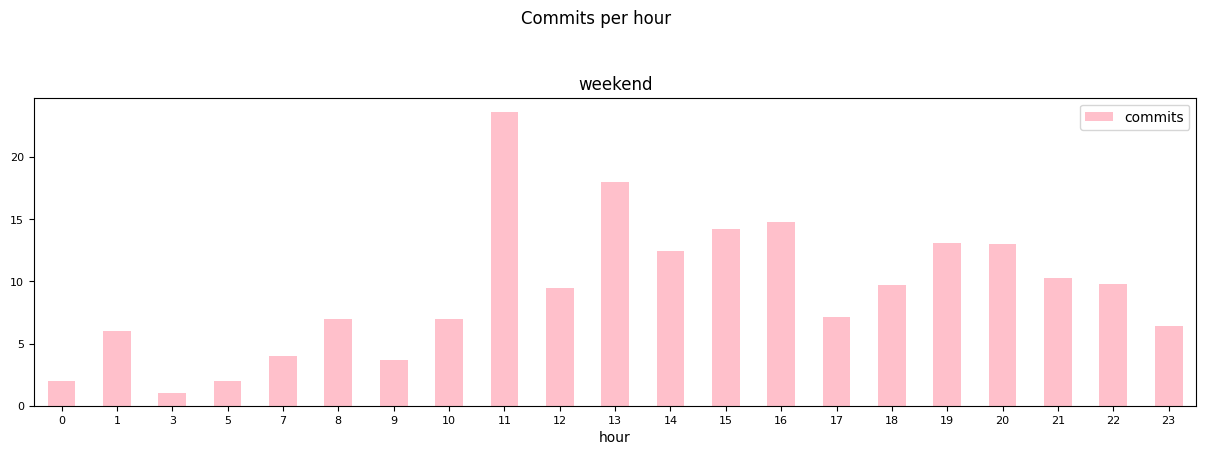

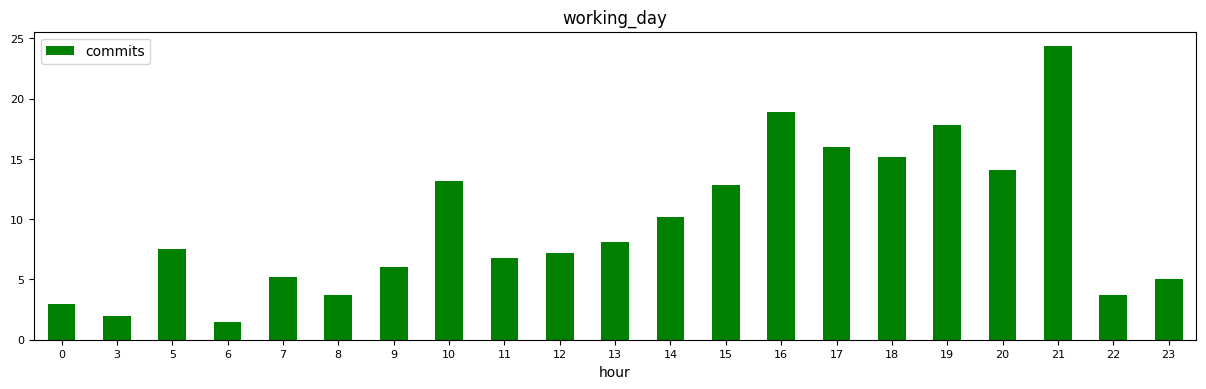

In [15]:
ax1 = weekend_days_avg[["commits"]].plot.bar(
    color="pink", 
    title="weekend",
    figsize=(15, 4), 
    fontsize=8, 
    xlabel="hour",
    rot=0
    )

ax1.figure.suptitle("Commits per hour", y=1.1)

ax2 = working_days_avg[["commits"]].plot.bar(
    color="green", 
    title="working_day", 
    figsize=(15, 4), 
    fontsize=8, 
    xlabel="hour",
    rot=0,
    legend=True
    )

ax2.legend(loc="upper left")

In [16]:
conn.close()

Вопросы:

Отличается ли динамика в рабочие и выходные дни?
Ответ: Да, в рабочие дни это 21:00, в выходные дни это 11:00